# U-Net mejorada para segmentación semántica de nubes

Notebook preparado para Kaggle. Entrena una variante **Attention Residual U-Net** ligera para comparar contra otros modelos.

Mejoras frente a la U-Net base:
- Bloques residuales con BatchNorm.
- Attention Gates en los skip connections.
- Data augmentation más completo pero liviano.
- Loss combinada: BCE + Dice + Focal.
- Mixed precision en GPU para acelerar.
- Scheduler OneCycleLR.
- Early stopping.
- Búsqueda de threshold óptimo en validación.

**Dataset esperado:** competencia *Understanding Clouds from Satellite Images* con:
- `train.csv`
- carpeta `train_images/`
- columna `Image_Label`
- columna `EncodedPixels`


## 1. Configuración general

In [1]:
import os
import json
import pickle
import random
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

LABELS = ["Fish", "Flower", "Gravel", "Sugar"]
ORIGINAL_HEIGHT = 1400
ORIGINAL_WIDTH = 2100

CONFIG = {
    "input_dir": None,
    "output_dir": "/kaggle/working/attention_resunet_results",
    "epochs": 30,
    "batch_size": 8,
    "img_size": 384,
    "lr": 3e-4,
    "max_lr": 1e-3,
    "valid_size": 0.20,
    "num_workers": 2,
    "seed": 42,
    "threshold": 0.5,
    "early_stop_patience": 6,
    "min_delta": 0.0005,
    "use_amp": True,
    "grad_clip": 1.0,
    "weight_decay": 5e-5,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 2. Reproducibilidad y detección del dataset

In [2]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def show_kaggle_input_tree(base: Path = Path("/kaggle/input"), max_depth: int = 3, max_items: int = 80) -> None:
    """Muestra una vista corta de /kaggle/input para diagnosticar rutas en Kaggle."""
    if not base.exists():
        print("No existe /kaggle/input. ¿Estás corriendo fuera de Kaggle?")
        return

    print("Contenido detectado en /kaggle/input:")
    count = 0
    for path in sorted(base.rglob("*")):
        rel = path.relative_to(base)
        depth = len(rel.parts)
        if depth > max_depth:
            continue
        prefix = "  " * (depth - 1)
        kind = "/" if path.is_dir() else ""
        print(f"{prefix}- {rel}{kind}")
        count += 1
        if count >= max_items:
            print("... salida truncada ...")
            break


def find_csv_with_image_label(base: Path) -> Path | None:
    """Busca el CSV correcto aunque no se llame exactamente train.csv."""
    csv_files = list(base.rglob("*.csv"))
    for csv_path in csv_files:
        try:
            sample = pd.read_csv(csv_path, nrows=5)
            if {"Image_Label", "EncodedPixels"}.issubset(sample.columns):
                return csv_path
        except Exception:
            pass
    return None


def find_image_dir_near(csv_path: Path) -> Path | None:
    """Busca una carpeta de imágenes compatible cerca del CSV."""
    root = csv_path.parent
    preferred_names = ["train_images", "images", "train"]

    for name in preferred_names:
        candidate = root / name
        if candidate.exists() and candidate.is_dir():
            if any(candidate.glob("*.jpg")) or any(candidate.glob("*.png")):
                return candidate

    # Búsqueda flexible: cualquier carpeta cercana con imágenes.
    for directory in [root] + [p for p in root.rglob("*") if p.is_dir()]:
        if any(directory.glob("*.jpg")) or any(directory.glob("*.png")):
            return directory
    return None


def find_kaggle_dataset() -> tuple[Path, Path, Path]:
    """
    Detecta automáticamente:
    - carpeta raíz del dataset
    - CSV con Image_Label / EncodedPixels
    - carpeta de imágenes
    """
    base = Path("/kaggle/input")
    if not base.exists():
        raise FileNotFoundError("No existe /kaggle/input. Define CONFIG['input_dir'], CSV_PATH e IMAGE_DIR manualmente.")

    show_kaggle_input_tree(base)

    # Caso ideal: train.csv junto a train_images.
    for csv_path in base.rglob("train.csv"):
        image_dir = find_image_dir_near(csv_path)
        if image_dir is not None:
            print("\nDataset detectado automáticamente:")
            print("CSV:", csv_path)
            print("Imágenes:", image_dir)
            return csv_path.parent, csv_path, image_dir

    # Caso flexible: CSV con las columnas correctas pero otro nombre o estructura.
    csv_path = find_csv_with_image_label(base)
    if csv_path is not None:
        image_dir = find_image_dir_near(csv_path)
        if image_dir is not None:
            print("\nDataset detectado automáticamente con búsqueda flexible:")
            print("CSV:", csv_path)
            print("Imágenes:", image_dir)
            return csv_path.parent, csv_path, image_dir

    raise FileNotFoundError(
        "No encontré un CSV con columnas Image_Label y EncodedPixels ni una carpeta de imágenes en /kaggle/input.\n\n"
        "En Kaggle debes ir a Add data y agregar el dataset de la competencia/datos.\n"
        "Luego revisa la estructura que imprime esta celda y, si hace falta, define manualmente:\n\n"
        "CONFIG['input_dir'] = '/kaggle/input/NOMBRE_DEL_DATASET'\n"
        "CSV_PATH = Path('/kaggle/input/NOMBRE_DEL_DATASET/train.csv')\n"
        "IMAGE_DIR = Path('/kaggle/input/NOMBRE_DEL_DATASET/train_images')"
    )


seed_everything(CONFIG["seed"])

if CONFIG["input_dir"] is None:
    INPUT_DIR, CSV_PATH, IMAGE_DIR = find_kaggle_dataset()
else:
    INPUT_DIR = Path(CONFIG["input_dir"])
    CSV_PATH = INPUT_DIR / "train.csv"
    IMAGE_DIR = INPUT_DIR / "train_images"

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nRutas finales usadas:")
print("INPUT_DIR:", INPUT_DIR)
print("CSV_PATH:", CSV_PATH, "| existe:", CSV_PATH.exists())
print("IMAGE_DIR:", IMAGE_DIR, "| existe:", IMAGE_DIR.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

Contenido detectado en /kaggle/input:
- competitions/
  - competitions/understanding_cloud_organization/
    - competitions/understanding_cloud_organization/sample_submission.csv
    - competitions/understanding_cloud_organization/test_images/
    - competitions/understanding_cloud_organization/train.csv
    - competitions/understanding_cloud_organization/train_images/

Dataset detectado automáticamente:
CSV: /kaggle/input/competitions/understanding_cloud_organization/train.csv
Imágenes: /kaggle/input/competitions/understanding_cloud_organization/train_images

Rutas finales usadas:
INPUT_DIR: /kaggle/input/competitions/understanding_cloud_organization
CSV_PATH: /kaggle/input/competitions/understanding_cloud_organization/train.csv | existe: True
IMAGE_DIR: /kaggle/input/competitions/understanding_cloud_organization/train_images | existe: True
OUTPUT_DIR: /kaggle/working/attention_resunet_results


## 3. Funciones RLE y preparación del dataframe

In [3]:
def rle_to_mask(rle: str, height: int = ORIGINAL_HEIGHT, width: int = ORIGINAL_WIDTH) -> np.ndarray:
    """Convierte una máscara RLE de Kaggle a una matriz binaria de tamaño height x width."""
    if pd.isna(rle) or rle == "":
        return np.zeros((height, width), dtype=np.uint8)

    values = np.asarray(str(rle).split(), dtype=np.int64)
    starts = values[0::2] - 1
    lengths = values[1::2]

    mask = np.zeros(height * width, dtype=np.uint8)
    for start, length in zip(starts, lengths):
        mask[start:start + length] = 1

    # Kaggle codifica en orden column-major.
    return mask.reshape((width, height)).T


def prepare_dataframe(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df[["Image", "Label"]] = df["Image_Label"].str.split("_", expand=True)
    df = df[["Image", "Label", "EncodedPixels"]]
    df["EncodedPixels"] = df["EncodedPixels"].fillna("")

    pivot = df.pivot(index="Image", columns="Label", values="EncodedPixels").fillna("").reset_index()

    for label in LABELS:
        if label not in pivot.columns:
            pivot[label] = ""

    pivot[LABELS] = pivot[LABELS].fillna("")
    pivot["num_labels"] = (pivot[LABELS] != "").sum(axis=1)
    pivot["has_mask"] = (pivot["num_labels"] > 0).astype(int)
    return pivot[["Image"] + LABELS + ["num_labels", "has_mask"]]


df = prepare_dataframe(CSV_PATH)
df.to_csv(OUTPUT_DIR / "training_pivot.csv", index=False)

print(df.shape)
df.head()

(5546, 7)


Label,Image,Fish,Flower,Gravel,Sugar,num_labels,has_mask
0,0011165.jpg,264918 937 266318 937 267718 937 269118 937 27...,1355565 1002 1356965 1002 1358365 1002 1359765...,,,2,1
1,002be4f.jpg,233813 878 235213 878 236613 878 238010 881 23...,1339279 519 1340679 519 1342079 519 1343479 51...,,67495 350 68895 350 70295 350 71695 350 73095 ...,3,1
2,0031ae9.jpg,3510 690 4910 690 6310 690 7710 690 9110 690 1...,2047 703 3447 703 4847 703 6247 703 7647 703 9...,,658170 388 659570 388 660970 388 662370 388 66...,3,1
3,0035239.jpg,,100812 462 102212 462 103612 462 105012 462 10...,65400 380 66800 380 68200 380 69600 380 71000 ...,,2,1
4,003994e.jpg,2367966 18 2367985 2 2367993 8 2368002 62 2369...,,353317 416 354717 416 356117 416 357517 416 35...,28011 489 29411 489 30811 489 32211 489 33611 ...,3,1


## 4. Split de entrenamiento y validación

In [4]:
train_df, valid_df = train_test_split(
    df,
    test_size=CONFIG["valid_size"],
    random_state=CONFIG["seed"],
    stratify=df["num_labels"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
valid_df.to_csv(OUTPUT_DIR / "valid_split.csv", index=False)

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Distribución train:")
print(train_df["num_labels"].value_counts(normalize=True).sort_index())
print("\nDistribución valid:")
print(valid_df["num_labels"].value_counts(normalize=True).sort_index())

Train: (4436, 7)
Valid: (1110, 7)
Distribución train:
num_labels
1    0.243012
2    0.427638
3    0.281335
4    0.048016
Name: proportion, dtype: float64

Distribución valid:
num_labels
1    0.243243
2    0.427928
3    0.281081
4    0.047748
Name: proportion, dtype: float64


## 5. Dataset y DataLoaders

In [5]:
class CloudSegmentationDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, image_dir: Path, img_size: int = 384, augment: bool = False) -> None:
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.img_size = img_size
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def _load_image(self, image_name: str) -> np.ndarray:
        image_path = self.image_dir / image_name
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(f"No se encontró la imagen: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)
        image = image.astype(np.float32) / 255.0
        return image

    def _load_mask(self, row: pd.Series) -> np.ndarray:
        masks = []
        for label in LABELS:
            mask = rle_to_mask(row[label])
            mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
            masks.append(mask)
        return np.stack(masks, axis=-1).astype(np.float32)

    def _augment(self, image: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if random.random() < 0.5:
            image = np.fliplr(image).copy()
            mask = np.fliplr(mask).copy()
        if random.random() < 0.5:
            image = np.flipud(image).copy()
            mask = np.flipud(mask).copy()

        if random.random() < 0.5:
            k = random.randint(1, 3)
            image = np.rot90(image, k).copy()
            mask = np.rot90(mask, k).copy()

        if random.random() < 0.4:
            factor = random.uniform(0.85, 1.20)
            image = np.clip(image * factor, 0, 1)

        if random.random() < 0.3:
            contrast = random.uniform(0.85, 1.20)
            mean = image.mean(axis=(0, 1), keepdims=True)
            image = np.clip((image - mean) * contrast + mean, 0, 1)

        if random.random() < 0.2:
            gamma = random.uniform(0.85, 1.15)
            image = np.clip(image ** gamma, 0, 1)

        # Ruido suave para mejorar generalización sin alterar la máscara.
        if random.random() < 0.15:
            noise = np.random.normal(0, 0.015, image.shape).astype(np.float32)
            image = np.clip(image + noise, 0, 1)

        return image, mask

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        row = self.df.iloc[idx]
        image = self._load_image(row["Image"])
        mask = self._load_mask(row)

        if self.augment:
            image, mask = self._augment(image, mask)

        image = torch.from_numpy(image.transpose(2, 0, 1)).float()
        mask = torch.from_numpy(mask.transpose(2, 0, 1)).float()
        return image, mask


train_dataset = CloudSegmentationDataset(train_df, IMAGE_DIR, img_size=CONFIG["img_size"], augment=True)
valid_dataset = CloudSegmentationDataset(valid_df, IMAGE_DIR, img_size=CONFIG["img_size"], augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG["num_workers"] > 0,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG["num_workers"] > 0,
)

images, masks = next(iter(train_loader))
print("Batch images:", images.shape)
print("Batch masks:", masks.shape)


Batch images: torch.Size([8, 3, 384, 384])
Batch masks: torch.Size([8, 4, 384, 384])


## 6. Visualización rápida de datos

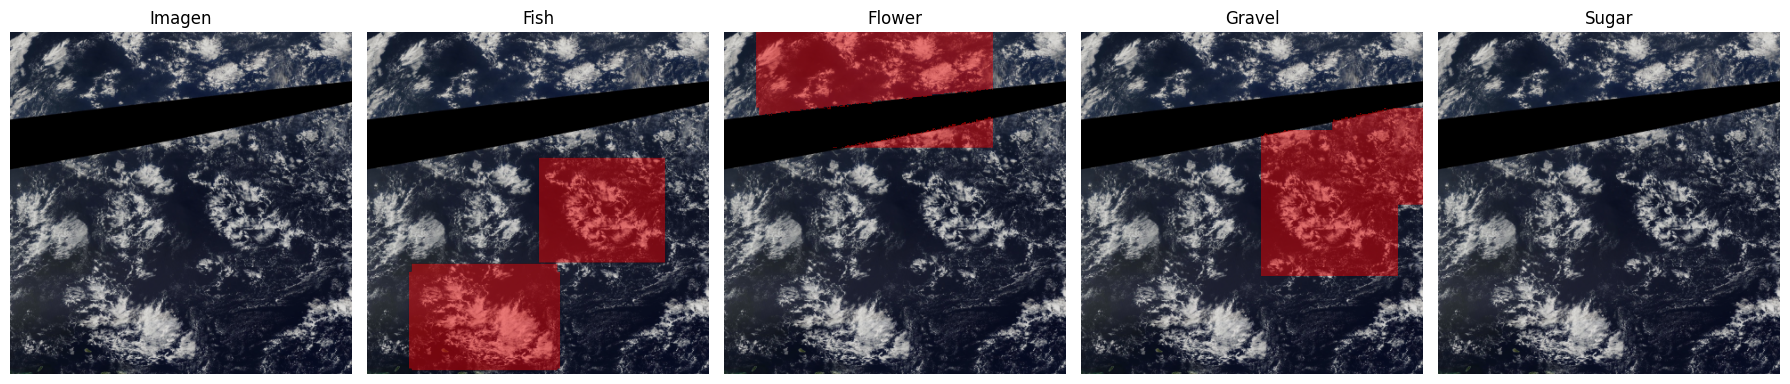

In [6]:
def overlay_mask(ax, image: np.ndarray, mask: np.ndarray, title: str):
    ax.imshow(image)
    masked = np.ma.masked_where(mask <= 0, mask)
    ax.imshow(masked, alpha=0.45, cmap="autumn")
    ax.set_title(title)
    ax.axis("off")


def show_sample(dataset, idx: int = 0):
    image, mask = dataset[idx]
    image_np = image.permute(1, 2, 0).numpy()
    mask_np = mask.numpy()

    fig, axes = plt.subplots(1, len(LABELS) + 1, figsize=(18, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Imagen")
    axes[0].axis("off")

    for i, label in enumerate(LABELS, start=1):
        overlay_mask(axes[i], image_np, mask_np[i - 1], label)

    plt.tight_layout()
    plt.show()

show_sample(train_dataset, 0)


## 7. Modelo Attention Residual U-Net

Esta versión sigue siendo una U-Net, pero agrega bloques residuales y compuertas de atención en los skip connections para mejorar el foco en regiones relevantes sin volver el entrenamiento demasiado pesado.

In [7]:
class ResidualConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float = 0.0) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.skip = (
            nn.Identity()
            if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        )
        self.act = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.conv(x) + self.skip(x))


class AttentionGate(nn.Module):
    def __init__(self, gate_channels: int, skip_channels: int, inter_channels: int) -> None:
        super().__init__()
        self.gate_proj = nn.Sequential(
            nn.Conv2d(gate_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.skip_proj = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_channels),
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, gate: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        if gate.shape[2:] != skip.shape[2:]:
            gate = F.interpolate(gate, size=skip.shape[2:], mode="bilinear", align_corners=False)
        attention = self.psi(self.relu(self.gate_proj(gate) + self.skip_proj(skip)))
        return skip * attention


class AttentionResidualUNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 3,
        out_channels: int = 4,
        features: List[int] | None = None,
        dropout: float = 0.10,
    ) -> None:
        super().__init__()
        if features is None:
            features = [32, 64, 128, 256]

        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        current_channels = in_channels
        for feature in features:
            self.downs.append(ResidualConvBlock(current_channels, feature, dropout=0.0))
            current_channels = feature

        self.bottleneck = ResidualConvBlock(features[-1], features[-1] * 2, dropout=dropout)

        self.up_transpose = nn.ModuleList()
        self.attentions = nn.ModuleList()
        self.up_blocks = nn.ModuleList()

        decoder_channels = features[-1] * 2
        for feature in reversed(features):
            self.up_transpose.append(
                nn.ConvTranspose2d(decoder_channels, feature, kernel_size=2, stride=2)
            )
            self.attentions.append(
                AttentionGate(gate_channels=feature, skip_channels=feature, inter_channels=max(feature // 2, 16))
            )
            self.up_blocks.append(
                ResidualConvBlock(feature * 2, feature, dropout=dropout / 2)
            )
            decoder_channels = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        skips = []

        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(len(self.up_transpose)):
            x = self.up_transpose[idx](x)
            skip = skips[idx]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            skip = self.attentions[idx](x, skip)
            x = torch.cat([skip, x], dim=1)
            x = self.up_blocks[idx](x)

        return self.final_conv(x)


model = AttentionResidualUNet(in_channels=3, out_channels=len(LABELS)).to(DEVICE)
print(model.__class__.__name__)
print("Parámetros:", sum(p.numel() for p in model.parameters() if p.requires_grad))


AttentionResidualUNet
Parámetros: 8199640


## 8. Loss, métricas y funciones de entrenamiento

In [8]:
class ComboSegmentationLoss(nn.Module):
    def __init__(self, smooth: float = 1.0, focal_gamma: float = 2.0, bce_weight: float = 0.5, dice_weight: float = 0.7, focal_weight: float = 0.2) -> None:
        super().__init__()
        self.smooth = smooth
        self.focal_gamma = focal_gamma
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.bce = nn.BCEWithLogitsLoss(reduction="none")

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)

        bce = self.bce(logits, targets)
        bce_loss = bce.mean()

        dims = (0, 2, 3)
        intersection = torch.sum(probs * targets, dims)
        cardinality = torch.sum(probs + targets, dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        dice_loss = 1.0 - dice.mean()

        pt = torch.exp(-bce)
        focal_loss = ((1.0 - pt) ** self.focal_gamma * bce).mean()

        return (
            self.bce_weight * bce_loss
            + self.dice_weight * dice_loss
            + self.focal_weight * focal_loss
        )


@torch.no_grad()
def compute_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5) -> Dict[str, float]:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    dims = (0, 2, 3)
    intersection = torch.sum(preds * targets, dims)
    union = torch.sum(preds + targets, dims) - intersection
    pred_sum = torch.sum(preds, dims)
    target_sum = torch.sum(targets, dims)

    eps = 1e-7
    dice_per_class = (2 * intersection + eps) / (pred_sum + target_sum + eps)
    iou_per_class = (intersection + eps) / (union + eps)

    metrics = {
        "dice_mean": dice_per_class.mean().item(),
        "iou_mean": iou_per_class.mean().item(),
    }
    for idx, label in enumerate(LABELS):
        metrics[f"dice_{label}"] = dice_per_class[idx].item()
        metrics[f"iou_{label}"] = iou_per_class[idx].item()
    return metrics


def merge_metric_dicts(metric_dicts: List[Dict[str, float]]) -> Dict[str, float]:
    keys = metric_dicts[0].keys()
    return {key: float(np.mean([m[key] for m in metric_dicts])) for key in keys}


def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None, scheduler=None) -> Dict[str, float]:
    model.train()
    losses = []
    metric_batches = []

    use_amp = scaler is not None and device.type == "cuda"

    for images, masks in tqdm(loader, desc="Training", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = criterion(logits, masks)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if CONFIG["grad_clip"] is not None:
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            if CONFIG["grad_clip"] is not None:
                nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            optimizer.step()

        if scheduler is not None:
            scheduler.step()

        losses.append(loss.item())
        metric_batches.append(compute_metrics(logits.detach(), masks.detach(), CONFIG["threshold"]))

    metrics = merge_metric_dicts(metric_batches)
    metrics["loss"] = float(np.mean(losses))
    return metrics


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device, threshold: float | None = None) -> Dict[str, float]:
    model.eval()
    losses = []
    metric_batches = []

    if threshold is None:
        threshold = CONFIG["threshold"]

    for images, masks in tqdm(loader, desc="Validation", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        losses.append(loss.item())
        metric_batches.append(compute_metrics(logits, masks, threshold))

    metrics = merge_metric_dicts(metric_batches)
    metrics["loss"] = float(np.mean(losses))
    return metrics


@torch.no_grad()
def find_best_threshold(model, loader, device, thresholds=None) -> Tuple[float, pd.DataFrame]:
    if thresholds is None:
        thresholds = np.round(np.arange(0.25, 0.76, 0.025), 3)

    model.eval()
    rows = []
    for threshold in thresholds:
        metric_batches = []
        for images, masks in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            logits = model(images)
            metric_batches.append(compute_metrics(logits, masks, float(threshold)))
        metrics = merge_metric_dicts(metric_batches)
        rows.append({"threshold": float(threshold), **metrics})

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["dice_mean"].idxmax()]
    return float(best_row["threshold"]), threshold_df


## 9. Entrenamiento

In [9]:
criterion = ComboSegmentationLoss(
    bce_weight=0.5,
    dice_weight=0.7,
    focal_weight=0.2,
    focal_gamma=2.0,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=CONFIG["max_lr"],
    epochs=CONFIG["epochs"],
    steps_per_epoch=steps_per_epoch,
    pct_start=0.15,
    div_factor=10.0,
    final_div_factor=200.0,
)

scaler = torch.cuda.amp.GradScaler(enabled=(CONFIG["use_amp"] and DEVICE.type == "cuda"))

run_config = CONFIG.copy()
run_config["input_dir"] = str(INPUT_DIR)
run_config["device"] = str(DEVICE)
run_config["labels"] = LABELS
run_config["model"] = "AttentionResidualUNet"
run_config["loss"] = "0.5*BCE + 0.7*DiceLoss + 0.2*FocalLoss"
run_config["scheduler"] = "OneCycleLR"

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(run_config, f, indent=2)

best_dice = -1.0
best_epoch = 0
epochs_without_improvement = 0
history = []

for epoch in range(1, CONFIG["epochs"] + 1):
    print(f"\nEpoch {epoch}/{CONFIG['epochs']}")
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE,
        scaler=scaler,
        scheduler=scheduler,
    )
    valid_metrics = validate_one_epoch(model, valid_loader, criterion, DEVICE)

    row = {"epoch": epoch, "lr": optimizer.param_groups[0]["lr"]}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in valid_metrics.items()})
    history.append(row)

    print(
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={valid_metrics['loss']:.4f} | "
        f"val_dice={valid_metrics['dice_mean']:.4f} | "
        f"val_iou={valid_metrics['iou_mean']:.4f} | "
        f"lr={optimizer.param_groups[0]['lr']:.2e}"
    )

    if valid_metrics["dice_mean"] > best_dice + CONFIG["min_delta"]:
        best_dice = valid_metrics["dice_mean"]
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_dice": best_dice,
                "config": run_config,
            },
            OUTPUT_DIR / "best_attention_resunet_model.pt",
        )
        print("Nuevo mejor modelo guardado.")
    else:
        epochs_without_improvement += 1
        print(f"Sin mejora relevante: {epochs_without_improvement}/{CONFIG['early_stop_patience']}")

    if epochs_without_improvement >= CONFIG["early_stop_patience"]:
        print("Early stopping activado.")
        break

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False) 
print("Mejor Dice validación:", best_dice, "| epoch:", best_epoch)
history_df.tail()



Epoch 1/30


/tmp/ipykernel_198/2351490408.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CONFIG["use_amp"] and DEVICE.type == "cuda"))


Training:   0%|          | 0/555 [00:00<?, ?it/s]

/tmp/ipykernel_198/3003699967.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Validation:   0%|          | 0/139 [00:00<?, ?it/s]

...

train_loss=0.5120 | val_loss=0.5259 | val_dice=0.5655 | val_iou=0.4114 | lr=4.27e-06
Sin mejora relevante: 4/6

Epoch 30/30


Training:   0%|          | 0/555 [00:00<?, ?it/s]

Validation:   0%|          | 0/139 [00:00<?, ?it/s]

train_loss=0.5157 | val_loss=0.5252 | val_dice=0.5686 | val_iou=0.4142 | lr=5.00e-07
Nuevo mejor modelo guardado.
Mejor Dice validación: 0.5686362016972878 | epoch: 30


,epoch,lr,train_dice_mean,train_iou_mean,train_dice_Fish,train_iou_Fish,train_dice_Flower,train_iou_Flower,train_dice_Gravel,train_iou_Gravel,...,val_iou_mean,val_dice_Fish,val_iou_Fish,val_dice_Flower,val_iou_Flower,val_dice_Gravel,val_iou_Gravel,val_dice_Sugar,val_iou_Sugar,val_loss
25,26,5.991168e-05,0.574698,0.419063,0.498741,0.343729,0.641724,0.489982,0.536397,0.382026,...,0.408830,0.477809,0.328184,0.645615,0.494062,0.527961,0.374770,0.599814,0.438306,0.526665
26,27,3.420694e-05,0.578750,0.422627,0.504149,0.347929,0.647174,0.495716,0.543103,0.386490,...,0.413211,0.474212,0.325955,0.650469,0.498849,0.536741,0.382066,0.607976,0.445975,0.525195
27,28,1.556693e-05,0.579836,0.424202,0.505782,0.348697,0.644682,0.496038,0.541623,0.386511,...,0.411015,0.474161,0.325755,0.649051,0.497515,0.526398,0.373670,0.609280,0.447121,0.524176
28,29,4.274230e-06,0.581725,0.426326,0.510747,0.353320,0.653507,0.503592,0.540369,0.386450,...,0.411368,0.478343,0.328942,0.643823,0.492103,0.531777,0.378186,0.608241,0.446242,0.525910
29,30,5.000123e-07,0.577268,0.422205,0.503420,0.347726,0.645252,0.495928,0.540687,0.385620,...,0.414240,0.478814,0.329400,0.649645,0.498261,0.536454,0.381782,0.609632,0.447516,0.525234


## 10. Curvas de entrenamiento

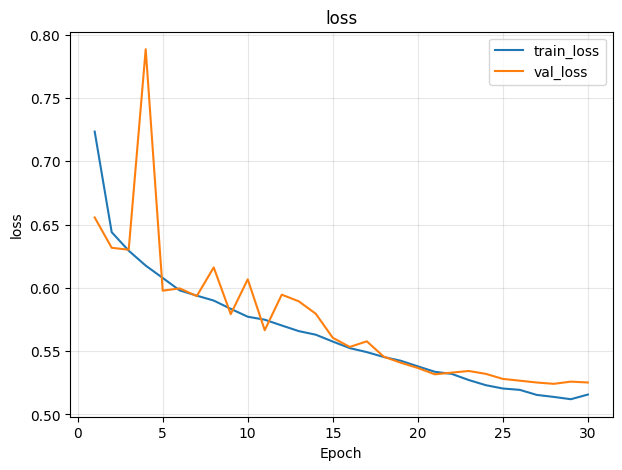

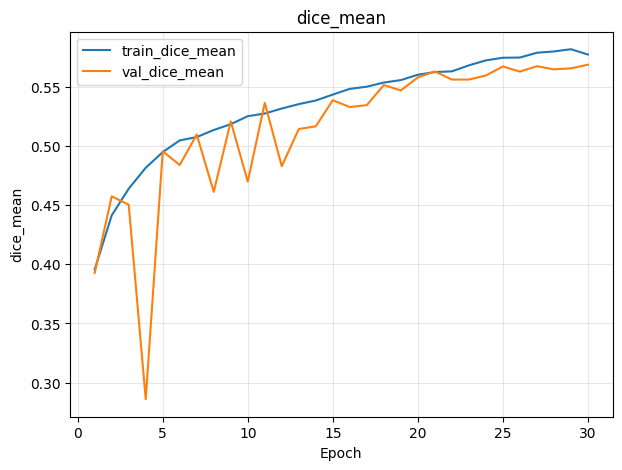

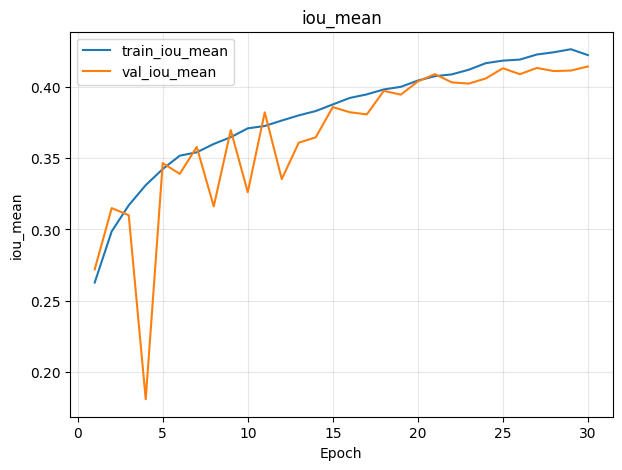

In [10]:
def plot_training_history(history_df: pd.DataFrame, output_dir: Path) -> None:
    for metric in ["loss", "dice_mean", "iou_mean"]:
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.plot(history_df["epoch"], history_df[f"train_{metric}"], label=f"train_{metric}")
        ax.plot(history_df["epoch"], history_df[f"val_{metric}"], label=f"val_{metric}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.set_title(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)
        fig.savefig(output_dir / f"history_{metric}.png", dpi=150, bbox_inches="tight")
        plt.show()

plot_training_history(history_df, OUTPUT_DIR)

## 11. Resultados comparables por clase

In [11]:
checkpoint = torch.load(OUTPUT_DIR / "best_attention_resunet_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

best_threshold, threshold_df = find_best_threshold(model, valid_loader, DEVICE)
threshold_df.to_csv(OUTPUT_DIR / "threshold_search.csv", index=False)
CONFIG["threshold"] = best_threshold

print("Mejor threshold en validación:", best_threshold)
display(threshold_df)

final_valid_metrics = validate_one_epoch(model, valid_loader, criterion, DEVICE, threshold=best_threshold)

final_results = {
    "model": "AttentionResidualUNet",
    "best_epoch": int(checkpoint["epoch"]),
    "best_val_dice_training_threshold_0_5": float(checkpoint["best_dice"]),
    "best_threshold": best_threshold,
}
final_results.update({f"val_{k}": v for k, v in final_valid_metrics.items()})

with open(OUTPUT_DIR / "final_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, indent=2)

metric_cols = [
    "val_dice_mean", "val_iou_mean",
    "val_dice_Fish", "val_dice_Flower", "val_dice_Gravel", "val_dice_Sugar",
    "val_iou_Fish", "val_iou_Flower", "val_iou_Gravel", "val_iou_Sugar",
    "val_loss",
]

summary_metrics = pd.DataFrame([final_results])
summary_metrics[["model", "best_epoch", "best_threshold"] + metric_cols]


Mejor threshold en validación: 0.4


,threshold,dice_mean,iou_mean,dice_Fish,iou_Fish,dice_Flower,iou_Flower,dice_Gravel,iou_Gravel,dice_Sugar,iou_Sugar
0,0.250,0.562238,0.406404,0.477384,0.326651,0.640817,0.488481,0.529291,0.372434,0.601460,0.438049
1,0.275,0.565161,0.409368,0.480534,0.329568,0.643326,0.491194,0.532379,0.375609,0.604406,0.441102
2,0.300,0.567486,0.411763,0.482894,0.331810,0.645338,0.493390,0.534898,0.378233,0.606815,0.443621
3,0.325,0.569225,0.413593,0.484482,0.333360,0.646869,0.495071,0.536878,0.380340,0.608671,0.445600
4,0.350,0.570503,0.414974,0.485408,0.334321,0.648098,0.496435,0.538494,0.382074,0.610011,0.447066
5,0.375,0.571311,0.415898,0.485766,0.334757,0.648987,0.497441,0.539529,0.383253,0.610963,0.448140
6,0.400,0.571624,0.416352,0.485495,0.334634,0.649582,0.498122,0.539937,0.383868,0.611482,0.448785
7,0.425,0.571510,0.416407,0.484675,0.334040,0.649930,0.498529,0.539821,0.384004,0.611613,0.449055
8,0.450,0.570957,0.416055,0.483282,0.332957,0.650057,0.498689,0.539180,0.383685,0.611308,0.448887
9,0.475,0.570003,0.415337,0.481356,0.331433,0.649946,0.498583,0.538024,0.382918,0.610686,0.448415


Validation:   0%|          | 0/139 [00:00<?, ?it/s]

,model,best_epoch,best_threshold,val_dice_mean,val_iou_mean,val_dice_Fish,val_dice_Flower,val_dice_Gravel,val_dice_Sugar,val_iou_Fish,val_iou_Flower,val_iou_Gravel,val_iou_Sugar,val_loss
0,AttentionResidualUNet,30,0.4,0.571624,0.416352,0.485495,0.649582,0.539937,0.611482,0.334634,0.498122,0.383868,0.448785,0.525234


## 12. Visualización de predicciones

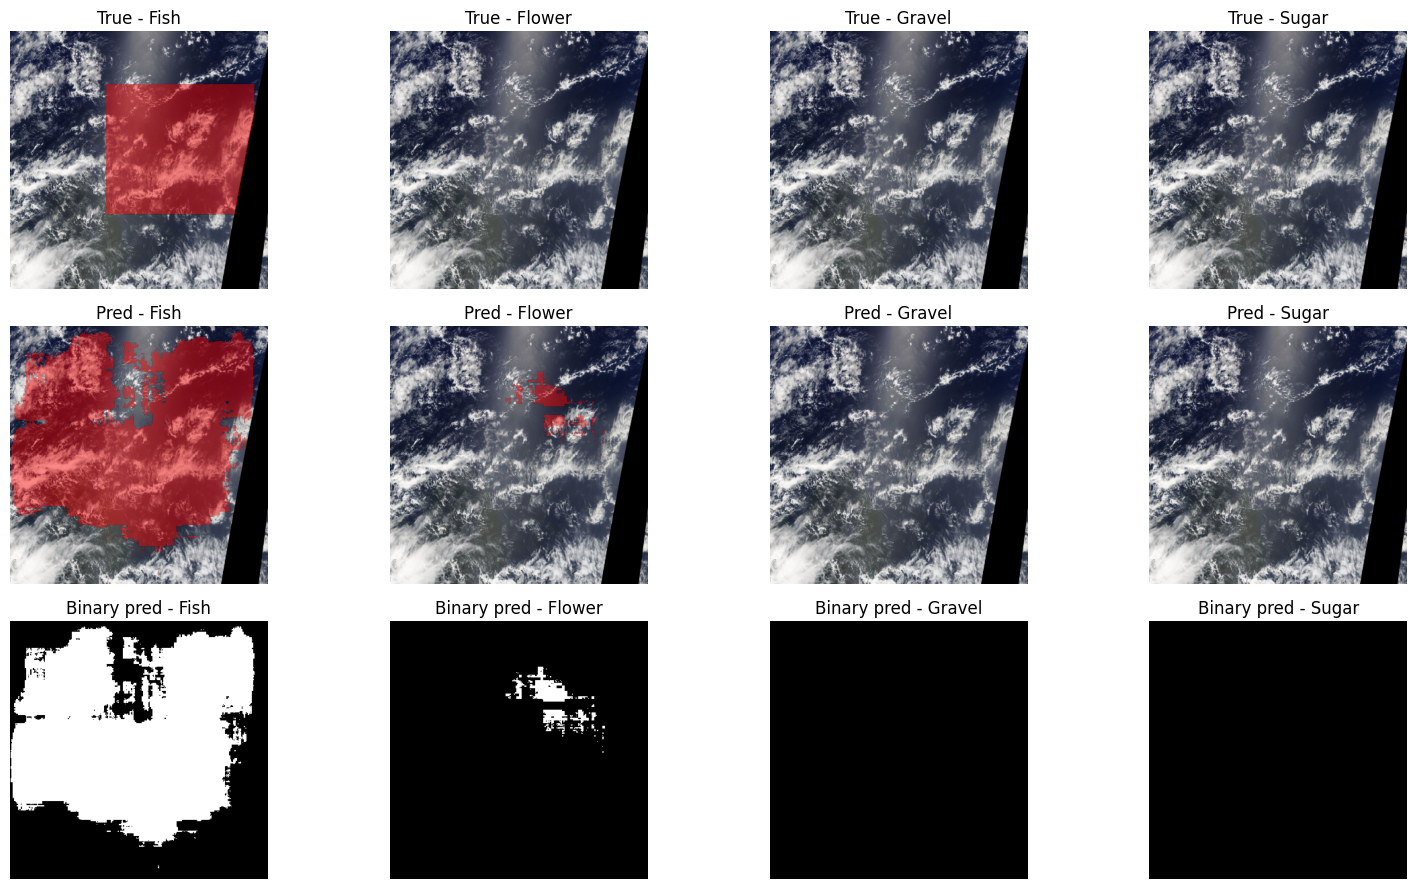

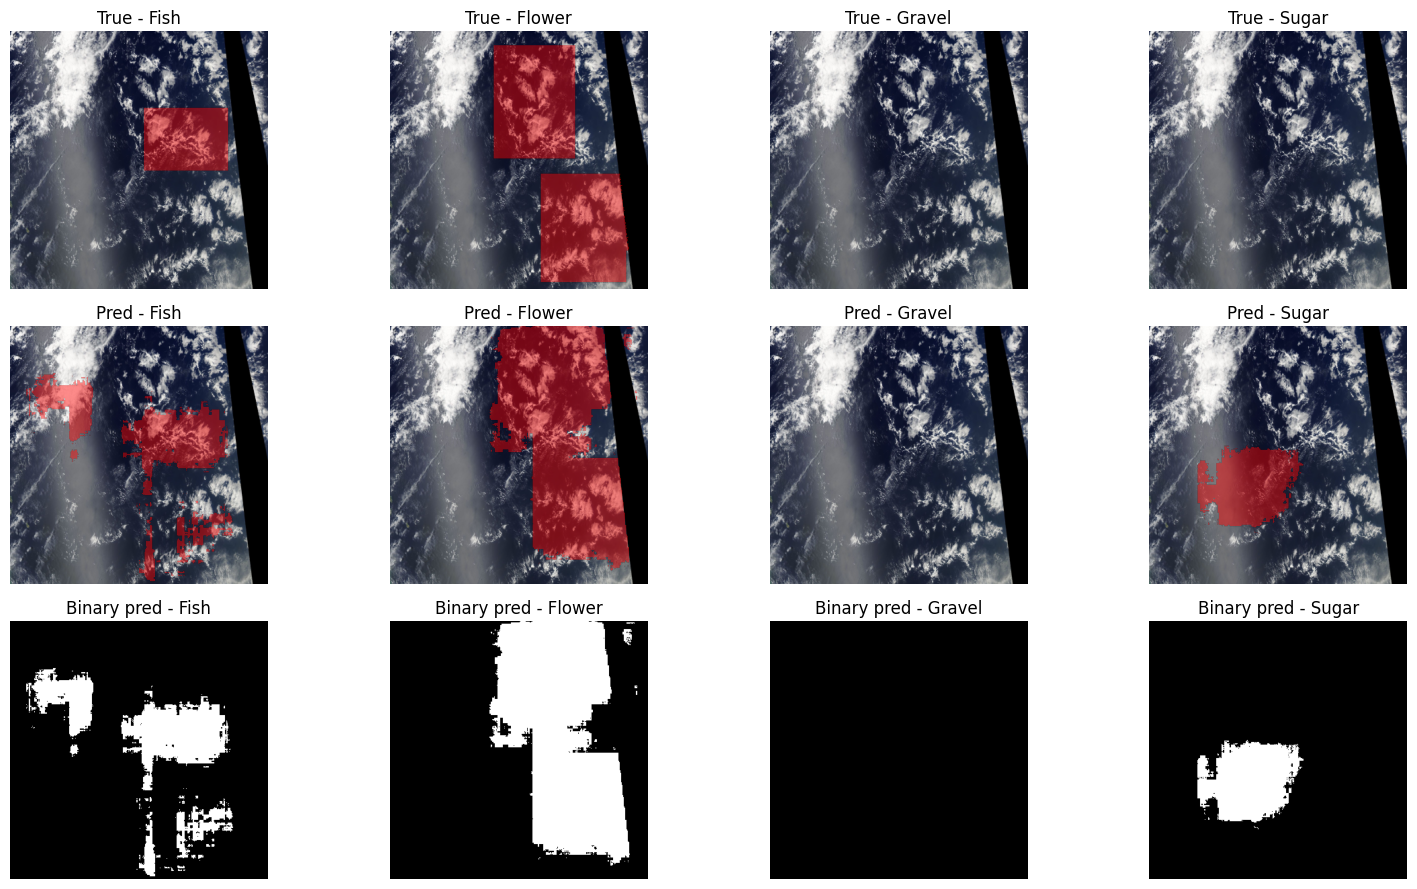

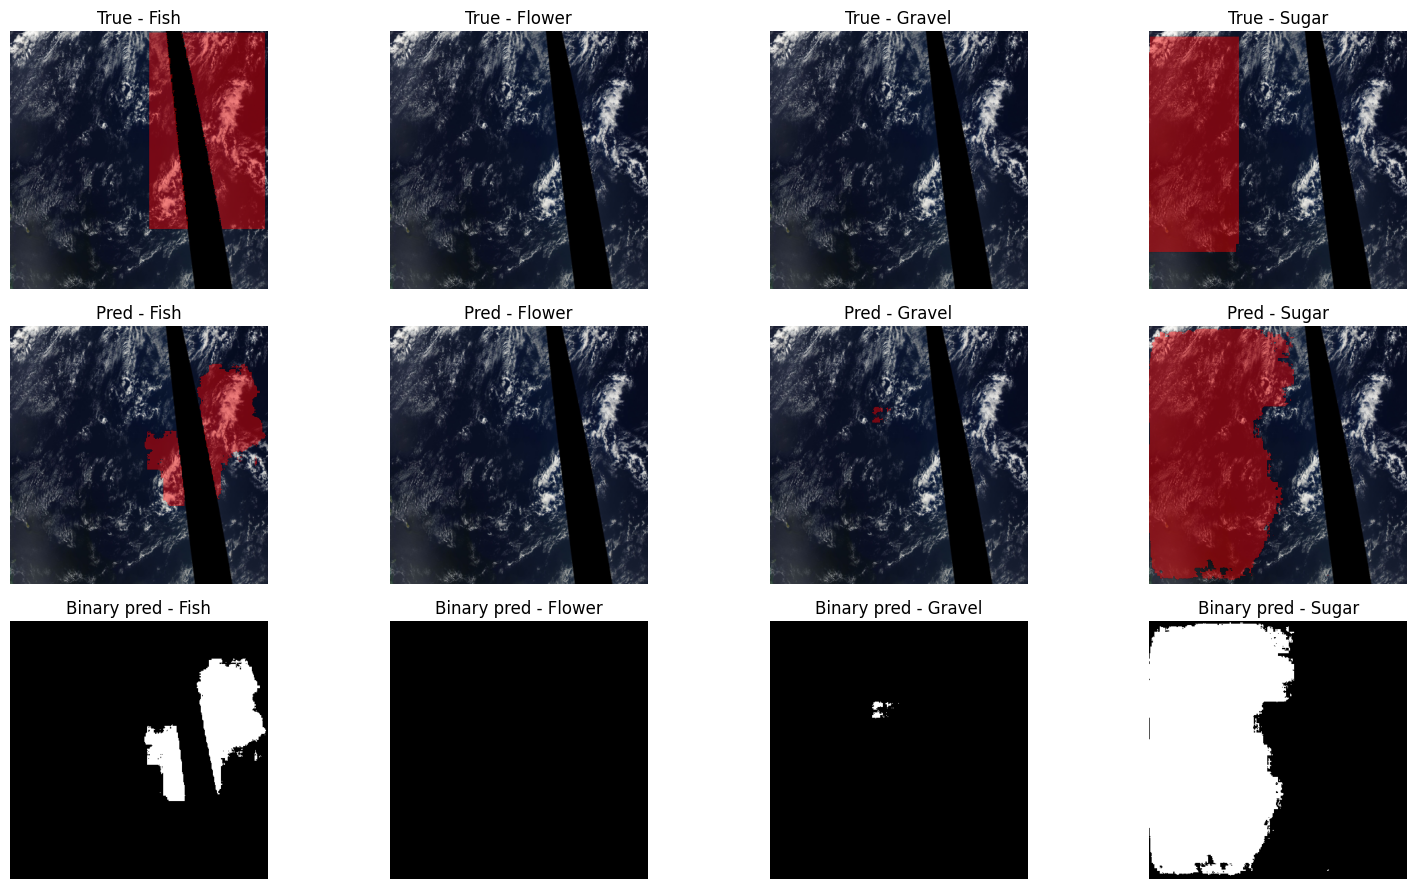

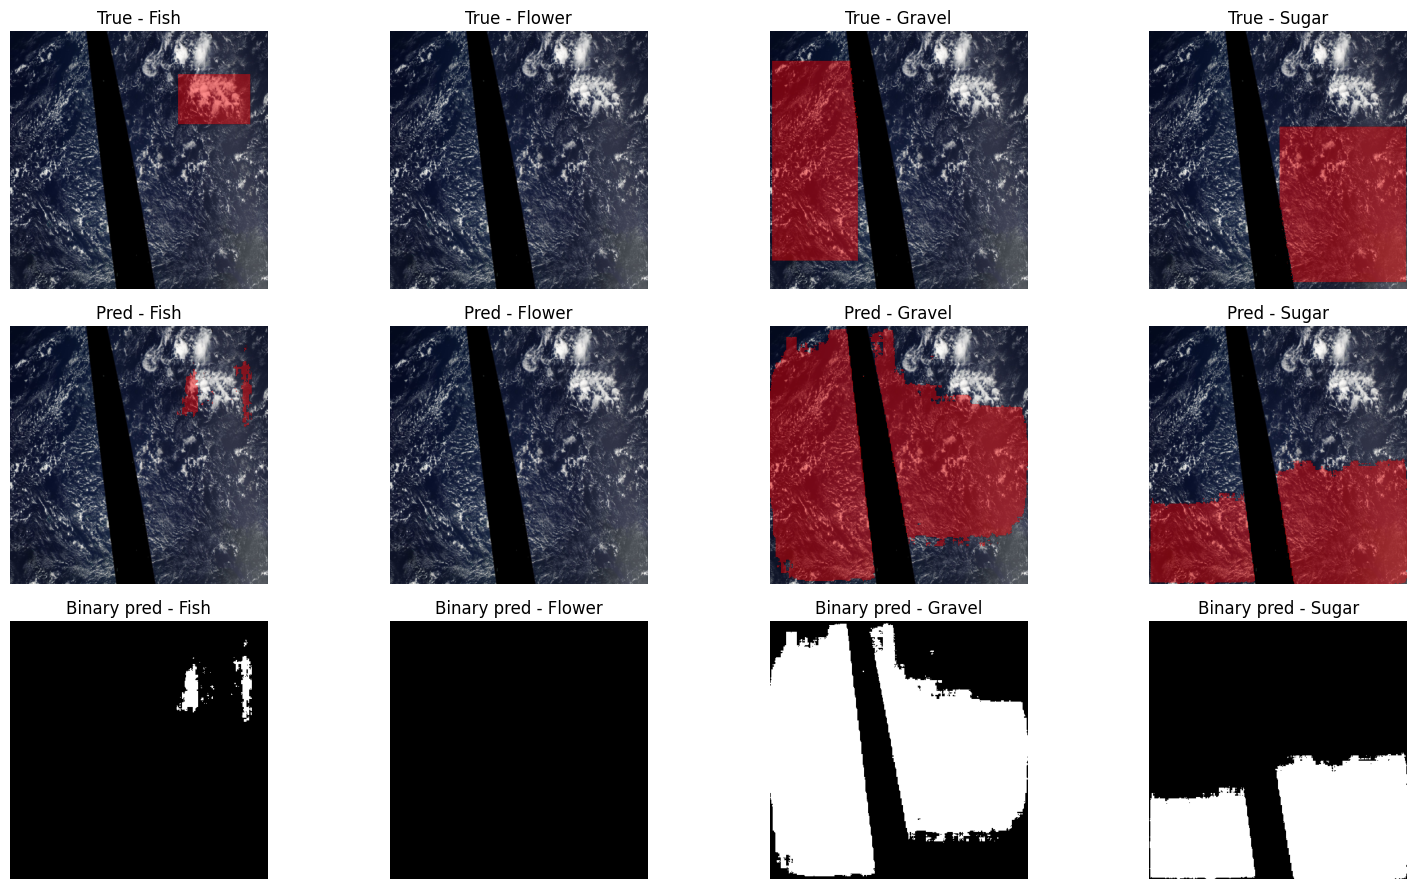

Resultados guardados en: /kaggle/working/attention_resunet_results


In [12]:
@torch.no_grad()
def save_prediction_examples(model, dataset, device, output_dir: Path, n_examples: int = 4, threshold: float = 0.5) -> None:
    model.eval()
    output_dir.mkdir(parents=True, exist_ok=True)

    indices = np.linspace(0, len(dataset) - 1, min(n_examples, len(dataset)), dtype=int)
    for plot_idx, idx in enumerate(indices, start=1):
        image, true_mask = dataset[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred_prob = torch.sigmoid(logits).squeeze(0).cpu()
        pred_mask = (pred_prob > threshold).float()

        img_np = image.permute(1, 2, 0).numpy()
        true_np = true_mask.numpy()
        pred_np = pred_mask.numpy()

        fig, axes = plt.subplots(3, len(LABELS), figsize=(16, 9))
        for class_idx, label in enumerate(LABELS):
            overlay_mask(axes[0, class_idx], img_np, true_np[class_idx], f"True - {label}")
            overlay_mask(axes[1, class_idx], img_np, pred_np[class_idx], f"Pred - {label}")
            axes[2, class_idx].imshow(pred_np[class_idx], cmap="gray")
            axes[2, class_idx].set_title(f"Binary pred - {label}")
            axes[2, class_idx].axis("off")

        plt.tight_layout()
        fig.savefig(output_dir / f"prediction_example_{plot_idx}.png", dpi=150)
        plt.show()
        plt.close(fig)


checkpoint = torch.load(OUTPUT_DIR / "best_attention_resunet_model.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

save_prediction_examples(
    model=model,
    dataset=valid_dataset,
    device=DEVICE,
    output_dir=OUTPUT_DIR / "prediction_examples",
    n_examples=4,
    threshold=CONFIG["threshold"],
)

print("Resultados guardados en:", OUTPUT_DIR)


In [13]:
@torch.no_grad()
def collect_validation_prediction_summary(model, dataset, device, threshold: float) -> pd.DataFrame:
    """
    Guarda un resumen liviano de las predicciones por imagen y clase.
    No almacena las máscaras completas para evitar que el .pkl quede innecesariamente pesado.
    """
    model.eval()
    rows = []

    for idx in tqdm(range(len(dataset)), desc="Resumen predicciones validación"):
        image, true_mask = dataset[idx]
        row_info = dataset.df.iloc[idx]

        logits = model(image.unsqueeze(0).to(device))
        probs = torch.sigmoid(logits).squeeze(0).cpu()
        pred_mask = (probs > threshold).float()

        for class_idx, label in enumerate(LABELS):
            rows.append({
                "image": row_info["Image"],
                "label": label,
                "threshold": float(threshold),
                "true_area_pct": float(true_mask[class_idx].mean().item()),
                "pred_area_pct": float(pred_mask[class_idx].mean().item()),
                "pred_prob_mean": float(probs[class_idx].mean().item()),
                "pred_prob_max": float(probs[class_idx].max().item()),
            })

    return pd.DataFrame(rows)


validation_prediction_summary = collect_validation_prediction_summary(
    model=model,
    dataset=valid_dataset,
    device=DEVICE,
    threshold=CONFIG["threshold"],
)

validation_prediction_summary.to_csv(OUTPUT_DIR / "validation_prediction_summary.csv", index=False)

resultados_modelo = {
    "model": "AttentionResidualUNet",
    "task_type": "semantic_segmentation",
    "labels": LABELS,
    "config": run_config,
    "best_epoch": int(checkpoint["epoch"]),
    "best_threshold": float(CONFIG["threshold"]),
    "best_val_dice_training_threshold_0_5": float(checkpoint["best_dice"]),
    "final_metrics": final_results,
    "training_history": history_df,
    "threshold_search": threshold_df,
    "validation_prediction_summary": validation_prediction_summary,
    "saved_files": {
        "model_weights": str(OUTPUT_DIR / "best_attention_resunet_model.pt"),
        "final_metrics_json": str(OUTPUT_DIR / "final_metrics.json"),
        "training_history_csv": str(OUTPUT_DIR / "training_history.csv"),
        "threshold_search_csv": str(OUTPUT_DIR / "threshold_search.csv"),
        "validation_prediction_summary_csv": str(OUTPUT_DIR / "validation_prediction_summary.csv"),
    },
}

with open(OUTPUT_DIR / "resultados_modelo.pkl", "wb") as f:
    pickle.dump(resultados_modelo, f)

print("Archivo .pkl guardado en:", OUTPUT_DIR / "resultados_modelo.pkl")
validation_prediction_summary.head()


Resumen predicciones validación:   0%|          | 0/1110 [00:00<?, ?it/s]

Archivo .pkl guardado en: /kaggle/working/attention_resunet_results/resultados_modelo.pkl


,image,label,threshold,true_area_pct,pred_area_pct,pred_prob_mean,pred_prob_max
0,493ad65.jpg,Fish,0.4,0.275899,0.566237,0.467728,0.945030
1,493ad65.jpg,Flower,0.4,0.000000,0.021559,0.049010,0.729015
2,493ad65.jpg,Gravel,0.4,0.000000,0.000000,0.015502,0.094961
3,493ad65.jpg,Sugar,0.4,0.000000,0.000000,0.010224,0.143990
4,5185dc3.jpg,Fish,0.4,0.000000,0.115370,0.127781,0.879645
